## ETERNA STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

eterna=pd.read_csv('../stock_data/eterna.csv') ## so it can be small letter. This is cool.
eterna=eterna.drop(columns=['high_price','low_price'])
eterna.rename(columns={'trade_date':'date'},inplace=True)
eterna['date']=pd.to_datetime(eterna['date'])
eterna['month']=eterna['date'].dt.month
eterna['quarter']=eterna['date'].dt.quarter
eterna['year']=eterna['date'].dt.year

eterna

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42851,ETERNA,2017-01-03,3.10,3.10,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43411,ETERNA,2017-01-04,3.06,3.06,216205,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43521,ETERNA,2017-01-05,3.20,3.20,603070,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43631,ETERNA,2017-01-06,3.30,3.30,954011,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43721,ETERNA,2017-01-09,3.20,3.20,769053,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298055,ETERNA,2026-07-13,28.80,28.80,262347,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298493,ETERNA,2026-07-14,28.80,28.80,228890,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298931,ETERNA,2026-07-15,28.80,28.80,117816,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299369,ETERNA,2026-07-16,28.80,28.80,359066,2026-07-16T15:10:03.113936+00:00,7,3,2026


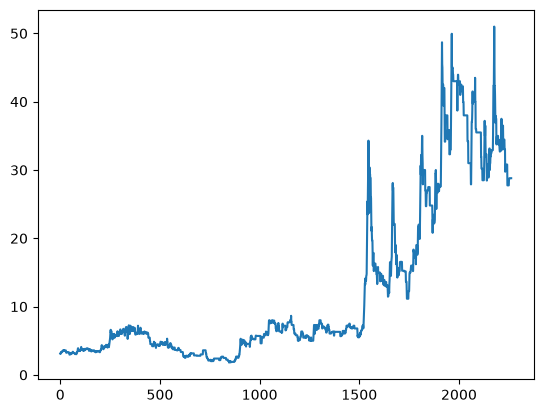

In [2]:
import matplotlib.pyplot as plt

plt.plot(eterna['close_price'])
plt.show()

In [3]:
eterna_end_month_df = (
    eterna
    .sort_values("date")
    .groupby(eterna["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

eterna_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45421,ETERNA,2017-01-31,3.62,3.62,208442,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47244,ETERNA,2017-02-28,3.28,3.28,236655,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49360,ETERNA,2017-03-31,3.39,3.39,265797,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51187,ETERNA,2017-04-28,3.03,3.03,173500,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53110,ETERNA,2017-05-31,3.73,3.73,313690,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35293,ETERNA,2026-03-31,34.90,34.90,983209,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281119,ETERNA,2026-04-30,32.80,32.80,4637255,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284185,ETERNA,2026-05-29,34.45,34.45,280144,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294113,ETERNA,2026-06-30,27.75,27.75,133041,2026-06-30T15:10:03.08168+00:00,6,2,2026


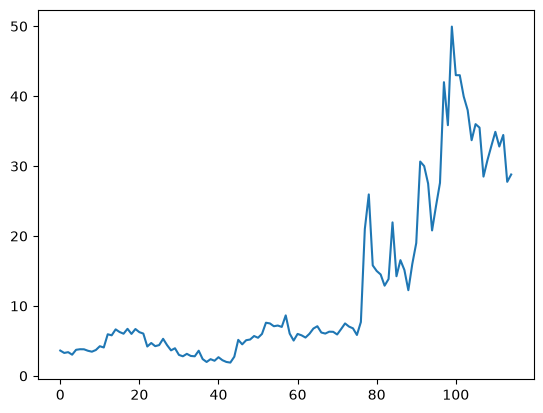

In [4]:
plt.plot(eterna_end_month_df['close_price'])
plt.show()

In [5]:
eterna_end_month_df['returns']=eterna_end_month_df['close_price'].pct_change()*100
eterna_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45421,ETERNA,2017-01-31,3.62,3.62,208442,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47244,ETERNA,2017-02-28,3.28,3.28,236655,2026-04-08T02:44:45.006295+00:00,2,1,2017,-9.392265
2,49360,ETERNA,2017-03-31,3.39,3.39,265797,2026-04-08T02:45:42.281198+00:00,3,1,2017,3.353659
3,51187,ETERNA,2017-04-28,3.03,3.03,173500,2026-04-08T02:51:55.619599+00:00,4,2,2017,-10.619469
4,53110,ETERNA,2017-05-31,3.73,3.73,313690,2026-04-08T02:52:57.421655+00:00,5,2,2017,23.102310
...,...,...,...,...,...,...,...,...,...,...,...
110,35293,ETERNA,2026-03-31,34.90,34.90,983209,2026-03-31T15:00:02.085058+00:00,3,1,2026,6.079027
111,281119,ETERNA,2026-04-30,32.80,32.80,4637255,2026-04-30T15:00:02.170664+00:00,4,2,2026,-6.017192
112,284185,ETERNA,2026-05-29,34.45,34.45,280144,2026-05-29T15:00:02.455558+00:00,5,2,2026,5.030488
113,294113,ETERNA,2026-06-30,27.75,27.75,133041,2026-06-30T15:10:03.08168+00:00,6,2,2026,-19.448476


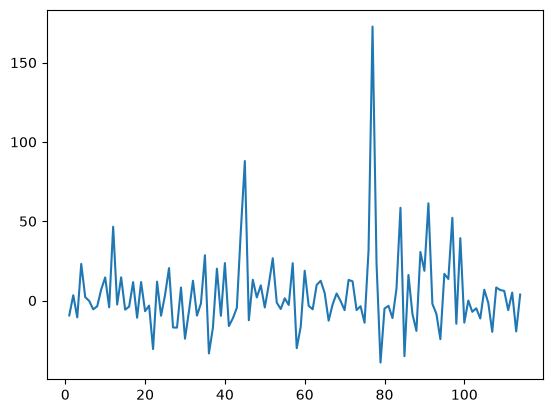

In [6]:
plt.plot(eterna_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(eterna_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.161735964363446), np.float64(7.477000644728e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(943.1823423359298))
stationary


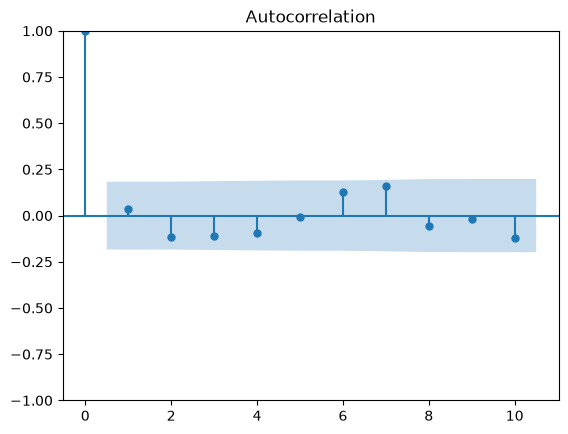

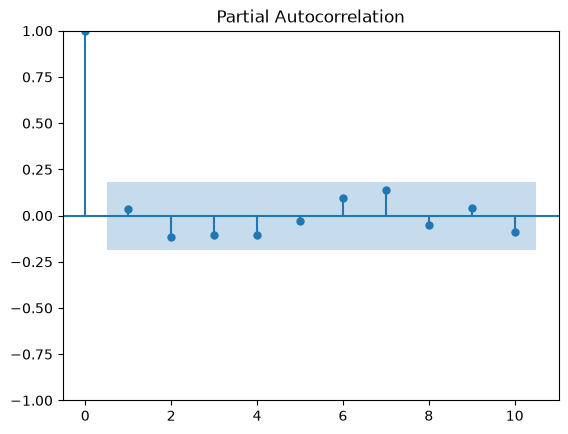

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(eterna_end_month_df['returns'].dropna(), lags=10)
plot_pacf(eterna_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=eterna_end_month_df['close_price'][:-10]
test=eterna_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -121.76759703585724]
[0, 0, 0, 0, 0, 1, -25.197563129899905]
[0, 0, 0, 0, 0, 2, -10.35361409521475]
[0, 0, 0, 0, 1, 0, -12.167832433999225]
[0, 0, 0, 0, 1, 1, -20.65272665953376]
[0, 0, 0, 0, 1, 2, -22.730371029082544]
[0, 0, 0, 0, 2, 0, -103.67678136957745]
[0, 0, 0, 0, 2, 1, -54.254335490614984]
[0, 0, 0, 0, 2, 2, -43.518209136509576]
[0, 0, 0, 1, 0, 0, -9.292503511455584]
[0, 0, 0, 1, 0, 1, -13.683009074555997]
[0, 0, 0, 1, 0, 2, -14.424406365221]
[0, 0, 0, 1, 1, 0, -28.651186439834937]
[0, 0, 0, 1, 1, 1, -28.623344678969243]
[0, 0, 0, 1, 1, 2, -23.791858206483106]
[0, 0, 0, 1, 2, 0, -46.77161857909217]
[0, 0, 0, 1, 2, 1, -46.09035794176793]
[0, 0, 0, 1, 2, 2, -45.476040694204755]
[0, 0, 0, 2, 0, 0, -16.76102333060374]
[0, 0, 0, 2, 0, 1, -16.41663129957649]
[0, 0, 0, 2, 0, 2, -13.750929941394899]
[0, 0, 0, 2, 1, 0, -24.75309907174947]
[0, 0, 0, 2, 1, 1, -24.823924032721422]
[0, 0, 0, 2, 1, 2, -24.800876614486953]
[0, 0, 0, 2, 2, 0, -45.887428806980985]
[0, 0, 0, 2

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-812.546504
654,2,2,0,0,2,0,-763.673136
655,2,2,0,0,2,1,-212.527947
412,1,2,0,0,2,1,-194.974012
651,2,2,0,0,1,0,-180.968930
...,...,...,...,...,...,...,...
290,1,0,1,2,0,2,-0.033542
513,2,0,1,0,0,0,0.115559
540,2,0,2,0,0,0,0.121375
270,1,0,1,0,0,0,0.214269


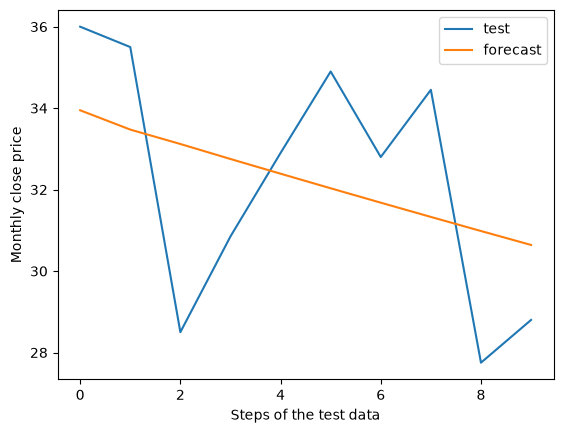

r2_score:  0.2200408176586569
rmse:  2.5806698683166713
description:  count    115.000000
mean      12.394609
std       12.156683
min        1.900000
25%        4.220000
50%        6.250000
75%       16.275000
max       49.950000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=eterna_end_month_df['close_price'][:-10]
y_test=eterna_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', eterna_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=eterna_end_month_df['returns'].dropna()[:-10]
test=eterna_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.009633607178048509]
[0, 0, 0, 0, 0, 1, -0.1508213302669843]
[0, 0, 0, 0, 0, 2, -0.189649785156774]
[0, 0, 0, 0, 1, 0, -6.312243804957479]
[0, 0, 0, 0, 1, 1, -1.8986320840406403]
[0, 0, 0, 0, 1, 2, -1.7563876138804941]
[0, 0, 0, 0, 2, 0, -33.957879364451564]
[0, 0, 0, 0, 2, 1, -8.473332093427091]
[0, 0, 0, 0, 2, 2, -7.52347889979851]
[0, 0, 0, 1, 0, 0, -0.1288408662588192]
[0, 0, 0, 1, 0, 1, -0.2103409071892024]
[0, 0, 0, 1, 0, 2, -0.0321147983017982]
[0, 0, 0, 1, 1, 0, -3.295748158956828]
[0, 0, 0, 1, 1, 1, -1.762576255188688]
[0, 0, 0, 1, 1, 2, -2.020935841597556]
[0, 0, 0, 1, 2, 0, -19.247095292198413]
[0, 0, 0, 1, 2, 1, -5.120681047541467]
[0, 0, 0, 1, 2, 2, -6.680571041135443]
[0, 0, 0, 2, 0, 0, -0.1364854921441665]
[0, 0, 0, 2, 0, 1, -0.08520174865219676]
[0, 0, 0, 2, 0, 2, -0.02967597386941412]
[0, 0, 0, 2, 1, 0, -9.732940096983995]
[0, 0, 0, 2, 1, 1, -1.8314011715309353]
[0, 0, 0, 2, 1, 2, -0.8727534904659189]
[0, 0, 0, 2, 2, 0, -8.798620792672601]
[0, 0, 0

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-8844.797880
177,0,2,0,1,2,0,-2277.881174
169,0,2,0,0,2,1,-1602.186859
186,0,2,0,2,2,0,-1397.127834
165,0,2,0,0,1,0,-1208.734276
...,...,...,...,...,...,...,...
290,1,0,1,2,0,2,-0.017958
270,1,0,1,0,0,0,-0.017246
0,0,0,0,0,0,0,-0.009634
542,2,0,2,0,0,2,0.128263


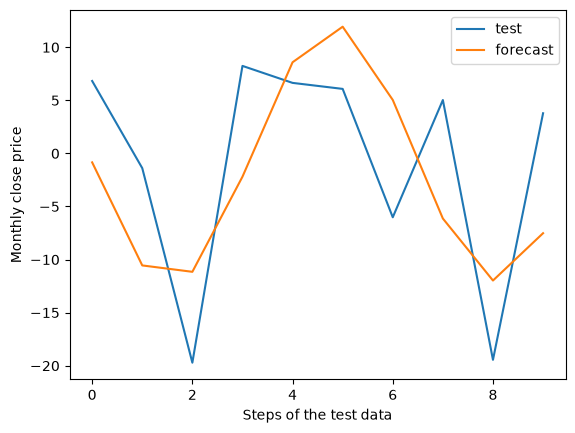

r2_score:  0.2298707675156203
rmse:  8.908812191613922
description:  count    114.000000
mean       4.220671
std       25.499439
min      -39.113680
25%       -9.159003
50%       -1.571637
75%       12.370760
max      172.727273
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=eterna_end_month_df['returns'].dropna()[:-10]
y_test=eterna_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', eterna_end_month_df.returns.dropna().describe())

Very good. We will work with returns
